In [73]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import time

In [74]:
# パラメーター
compare_month = 1

In [75]:
def load_and_filter_data(file_path):
    df = pd.read_csv(file_path)
    
    # check if ticker_code is a 4-digit number
    def is_four_digit_number(x):
        if isinstance(x, str):
            return x.isdigit() and len(x) == 4
        return False
    
    # filter data
    df_filtered = df[df['TICKER_CODE'].apply(is_four_digit_number)]
    
    # check the result
    print("original data:", len(df))
    print("filtered data:", len(df_filtered))
    
    return df_filtered

# load and filter data
df_filtered = load_and_filter_data('../../../DATAHUB/aba922ff-cef0-4bc7-8899-00fc08a14023.csv')
# df_filtered = load_and_filter_data('../data/Daily_fixed.csv')
df_filtered

original data: 38975
filtered data: 35269


,DATE,TICKER_CODE,TOTAL_SALES
0,2013-01,2138,985151
1,2013-02,2138,1177610
2,2013-03,2138,1852193
3,2013-04,2138,1595681
4,2013-05,2138,1997601
...,...,...,...
35264,2025-02,9997,59219415
35265,2025-03,9997,78720890
35266,2025-04,9997,67881188
35267,2025-05,9997,67086649


In [76]:
def calculate_monthly_growth(df_filtered):
    # convert DATE to datetime
    df_filtered['DATE'] = pd.to_datetime(df_filtered['DATE'])
    
    # # filter data from April 2021
    # start_date = pd.to_datetime('2021-04-01')
    # df_filtered = df_filtered[df_filtered['DATE'] >= start_date]
    
    # add 'year-month' column for monthly aggregation
    df_filtered['year-month'] = df_filtered['DATE'].dt.to_period('M')
    
    # sum by TICKER_CODE and year-month
    monthly_total = df_filtered.groupby(['year-month', 'TICKER_CODE'])['TOTAL_SALES'].sum().reset_index()
    monthly_total.rename(columns={'year-month': 'DATE'}, inplace=True)
    
    # calculate growth rate
    monthly_total['prev_month_sales'] = monthly_total.groupby('TICKER_CODE')['TOTAL_SALES'].shift(1)
    monthly_total['growth_rate'] = (monthly_total['TOTAL_SALES'] - monthly_total['prev_month_sales']) / monthly_total['prev_month_sales']
    monthly_total = monthly_total.dropna(subset=['growth_rate'])

    # growth rateのYoY
    monthly_total['prev_year_growth_rate'] = monthly_total.groupby('TICKER_CODE')['growth_rate'].shift(12)
    monthly_total['YoY'] = monthly_total['growth_rate'] - monthly_total['prev_year_growth_rate']
    monthly_total = monthly_total.dropna(subset=['YoY'])
    
    # exclude the latest month
    latest_month = monthly_total['DATE'].max()
    monthly_total = monthly_total[monthly_total['DATE'] != latest_month]
    
    # convert DATE to string
    monthly_total['DATE'] = monthly_total['DATE'].astype(str)
    
    return monthly_total



# calculate monthly growth rate
monthly_total = calculate_monthly_growth(df_filtered)

# 不要なカラムの削除
monthly_total = monthly_total.drop(columns=['TOTAL_SALES', 'prev_month_sales', 'growth_rate', 'prev_year_growth_rate'])

# order by TICKER_CODE AND DATE
monthly_total = monthly_total.sort_values(by=['TICKER_CODE', 'DATE'])

monthly_total

,DATE,TICKER_CODE,YoY
2922,2014-02,2138,-0.459727
3153,2014-03,2138,-0.330166
3384,2014-04,2138,0.525741
3615,2014-05,2138,-0.209207
3846,2014-06,2138,-0.142646
...,...,...,...
34296,2025-02,9997,0.108031
34534,2025-03,9997,0.226670
34772,2025-04,9997,-0.259355
35010,2025-05,9997,0.067446


In [77]:
# YoYとの比較
monthly_total['prev_month_YoY'] = monthly_total.groupby('TICKER_CODE')['YoY'].shift(compare_month)
monthly_total['compare_to_last_month'] = monthly_total['YoY'] - monthly_total['prev_month_YoY']

# nanの削除
yoy_data = monthly_total.dropna(subset=['compare_to_last_month'])

# 不要なカラムの削除
yoy_data = yoy_data.drop(columns=['prev_month_YoY'])

yoy_data

,DATE,TICKER_CODE,YoY,compare_to_last_month
3153,2014-03,2138,-0.330166,0.129561
3384,2014-04,2138,0.525741,0.855907
3615,2014-05,2138,-0.209207,-0.734947
3846,2014-06,2138,-0.142646,0.066561
4077,2014-07,2138,-0.037008,0.105638
...,...,...,...,...
34296,2025-02,9997,0.108031,0.245043
34534,2025-03,9997,0.226670,0.118639
34772,2025-04,9997,-0.259355,-0.486025
35010,2025-05,9997,0.067446,0.326801


In [78]:
quantile_data = []

# YoY, compare_to_last_monthを用いたquantileの作成
for date in yoy_data['DATE'].unique():
    date_data = yoy_data[yoy_data['DATE'] == date].copy()  # .copy()を追加

    date_data.loc[:, 'quantile_YoY'] = pd.qcut(date_data['YoY'], 4, labels=range(1, 4 + 1))
    date_data.loc[:, 'quantile_YoY_compare_to_last_month'] = pd.qcut(date_data['compare_to_last_month'], 4, labels=range(1, 4 + 1))

    quantile_data.append(date_data)

quantile_df = pd.concat(quantile_data)

quantile_df.dropna(inplace=True)

quantile_df

# quantile_data = []

# # YoY, compare_to_last_monthを用いたquantileの作成
# for date in yoy_data['DATE'].unique():
#     date_data = yoy_data[yoy_data['DATE'] == date]

#     date_data['quantile_YoY'] = pd.qcut(date_data['YoY'], 4, labels=range(1, 4 + 1))
#     date_data['quantile_YoY_compare_to_last_month'] = pd.qcut(date_data['compare_to_last_month'], 4, labels=range(1, 4 + 1))

#     quantile_data.append(date_data)

# quantile_df = pd.concat(quantile_data)

# quantile_df.dropna(inplace=True)

c:\Users\hh080\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4655: RuntimeWarning: invalid value encountered in multiply
  lerp_interpolation = asanyarray(add(a, diff_b_a * t, out=out))
c:\Users\hh080\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4655: RuntimeWarning: invalid value encountered in multiply
  lerp_interpolation = asanyarray(add(a, diff_b_a * t, out=out))
c:\Users\hh080\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
c:\Users\hh080\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
c:\Users\hh080\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4653: RuntimeWarning: invalid value encounte

,DATE,TICKER_CODE,YoY,compare_to_last_month,quantile_YoY,quantile_YoY_compare_to_last_month
3153,2014-03,2138,-0.330166,0.129561,1,2
3154,2014-03,2157,0.065176,0.213292,2,3
3155,2014-03,2193,-0.014162,-0.022846,1,1
3156,2014-03,2211,0.105233,0.192286,2,2
3157,2014-03,2267,0.685294,-4.704595,4,1
...,...,...,...,...,...,...
35262,2026-02,4478,-0.273959,-0.035364,4,4
35263,2026-03,3994,-0.241013,0.044998,4,4
35264,2026-03,4478,-0.408104,-0.134145,1,1
35265,2026-04,3994,-0.435040,-0.194026,1,1


In [79]:
# # quantile_YoY, quantile_YoY_compare_to_last_monthを図示 # temp
# quantile_df = quantile_df[quantile_df['DATE'] <= '2021-04-01']

# plt.figure(figsize=(15, 6))
# plt.plot(quantile_df.index, quantile_df['quantile_YoY'], label='quantile_YoY')
# plt.plot(quantile_df.index, quantile_df['quantile_YoY_compare_to_last_month'], label='quantile_YoY_compare_to_last_month')
# plt.xlabel('date')
# plt.ylabel('quantile')
# plt.legend()
# plt.grid(True)
# plt.xticks(rotation=45)
# plt.show()

In [80]:
# quantile_YoY, quantile_YoY_compare_to_last_monthから、新しいquantileを作成
quantile_df['sum_quantile'] = quantile_df['quantile_YoY'].astype(int) + quantile_df['quantile_YoY_compare_to_last_month'].astype(int)

# sum_quantileを用いたquantileの作成
quantile_df['quantile_sum_quantile'] = pd.qcut(quantile_df['sum_quantile'], 4, labels=range(1, 4 + 1))

quantile_df = quantile_df.drop(columns=['YoY', 'compare_to_last_month', 'quantile_YoY', 'quantile_YoY_compare_to_last_month', 'sum_quantile'])

quantile_df

,DATE,TICKER_CODE,quantile_sum_quantile
3153,2014-03,2138,1
3154,2014-03,2157,2
3155,2014-03,2193,1
3156,2014-03,2211,2
3157,2014-03,2267,2
...,...,...,...
35262,2026-02,4478,4
35263,2026-03,3994,4
35264,2026-03,4478,1
35265,2026-04,3994,1


In [81]:
# create portfolio weights by quantile

def create_portfolio_weights(quantile_df):
    portfolio_weights = []
    for date in quantile_df['DATE'].unique():
        date_quantiles = quantile_df[quantile_df['DATE'] == date]
        for quantile in range(1, 4 + 1):
            quantile_stocks = date_quantiles[date_quantiles['quantile_sum_quantile'] == quantile]
            if not quantile_stocks.empty:
                weight = 1.0 / len(quantile_stocks)
                for _, row in quantile_stocks.iterrows():
                    portfolio_weights.append({'DATE': date, 'TICKER_CODE': row['TICKER_CODE'], f'quantile_{quantile}': weight})
        
        portfolio_weights_df = pd.DataFrame(portfolio_weights)
        portfolio_weights_df = portfolio_weights_df.fillna(0)

    return portfolio_weights_df

portfolio_weights_df = create_portfolio_weights(quantile_df)

portfolio_weights_df

,DATE,TICKER_CODE,quantile_1,quantile_2,quantile_3,quantile_4
0,2014-03,2138,0.016393,0.0,0.0,0.0
1,2014-03,2193,0.016393,0.0,0.0,0.0
2,2014-03,2331,0.016393,0.0,0.0,0.0
3,2014-03,2371,0.016393,0.0,0.0,0.0
4,2014-03,2432,0.016393,0.0,0.0,0.0
...,...,...,...,...,...,...
31727,2026-02,4478,0.000000,0.0,0.0,1.0
31728,2026-03,4478,1.000000,0.0,0.0,0.0
31729,2026-03,3994,0.000000,0.0,0.0,1.0
31730,2026-04,3994,1.000000,0.0,0.0,0.0


In [82]:
# # save portfolio weights
# portfolio_weights_df.to_csv('../data/output/portfolio_weights.csv', index=False)

In [83]:
# load price data
price_data = pd.read_csv('../../../DATAHUB/Price_Data/price_data_for_cca.csv')

price_data = price_data.drop(columns=['DIVIDENDS'])

price_data

,DATE,TICKER_CODE,PRICE,monthly_return
0,2013-01,2138,923.174316,NaN
1,2013-02,2138,1558.038574,0.687697
2,2013-03,2138,1587.160767,0.028319
3,2013-04,2138,1977.104126,0.245686
4,2013-05,2138,3473.158691,0.756690
...,...,...,...,...
30499,2025-02,5032,2811.156250,-0.110972
30500,2025-03,5032,3201.704834,0.138928
30501,2025-04,5032,3667.587646,0.155662
30502,2025-05,5032,3950.000000,0.077002


In [84]:
# DATEの形式を統一
portfolio_weights_df['DATE'] = pd.to_datetime(portfolio_weights_df['DATE']).dt.strftime('%Y-%m')
price_data['DATE'] = pd.to_datetime(price_data['DATE']).dt.strftime('%Y-%m')

# TICKER_CODEの型を統一（文字列に変換）
portfolio_weights_df['TICKER_CODE'] = portfolio_weights_df['TICKER_CODE'].astype(str)
price_data['TICKER_CODE'] = price_data['TICKER_CODE'].astype(str)

# リターンマトリックスの作成
returns_matrix = price_data.pivot(index='DATE', columns='TICKER_CODE', values='monthly_return')

# 各クォンタイルのリターン計算
portfolio_returns = pd.DataFrame(index=returns_matrix.index)

# クォンタイル列の自動検出
quantile_cols = [col for col in portfolio_weights_df.columns if col.startswith('quantile_')]

for quantile_col in quantile_cols:
    # ウェイトの取得
    weights = portfolio_weights_df.pivot(index='DATE', columns='TICKER_CODE', values=quantile_col)

    # インデックスの整合性確認
    common_dates = weights.index.intersection(returns_matrix.index)

    if len(common_dates) == 0:
        print(f"Warning: No common dates found between weights and returns for {quantile_col}")
        continue

    # リターンの計算
    # 1. 共通の日付でデータを抽出
    weights_common = weights.loc[common_dates]
    returns_common = returns_matrix.loc[common_dates]
    
    # 2. 共通のカラム（銘柄）を取得
    common_columns = weights_common.columns.intersection(returns_common.columns)
    
    if len(common_columns) == 0:
        print("Warning: No common columns found between weights and returns")
        continue
        
    weights_common = weights_common[common_columns]
    returns_common = returns_common[common_columns]
    
    # 3. NaNを0に置換
    weights_common = weights_common.fillna(0)
    returns_common = returns_common.fillna(0)
    
    weighted_returns = weights_common * returns_common
    
    # 5. 合計を計算
    returns = weighted_returns.sum(axis=1)
    
    portfolio_returns[quantile_col] = returns

# NaNを除去
portfolio_returns = portfolio_returns.dropna()

portfolio_returns

,quantile_1,quantile_2,quantile_3,quantile_4
DATE,,,,
2014-03,0.005203,0.036971,0.024423,0.056209
2014-04,0.004019,0.005214,-0.011038,-0.040037
2014-05,0.033259,0.027646,0.033853,0.021785
2014-06,0.047151,0.053117,0.056285,0.027958
2014-07,0.011799,0.026698,0.025538,0.041811
...,...,...,...,...
2025-02,-0.032278,-0.018747,-0.021445,-0.003281
2025-03,0.020585,0.020532,0.029594,0.006648
2025-04,0.047261,0.050869,0.052919,0.024926


In [85]:
# # save portfolio returns
# portfolio_returns.to_csv('../data/output/portfolio_returns.csv')

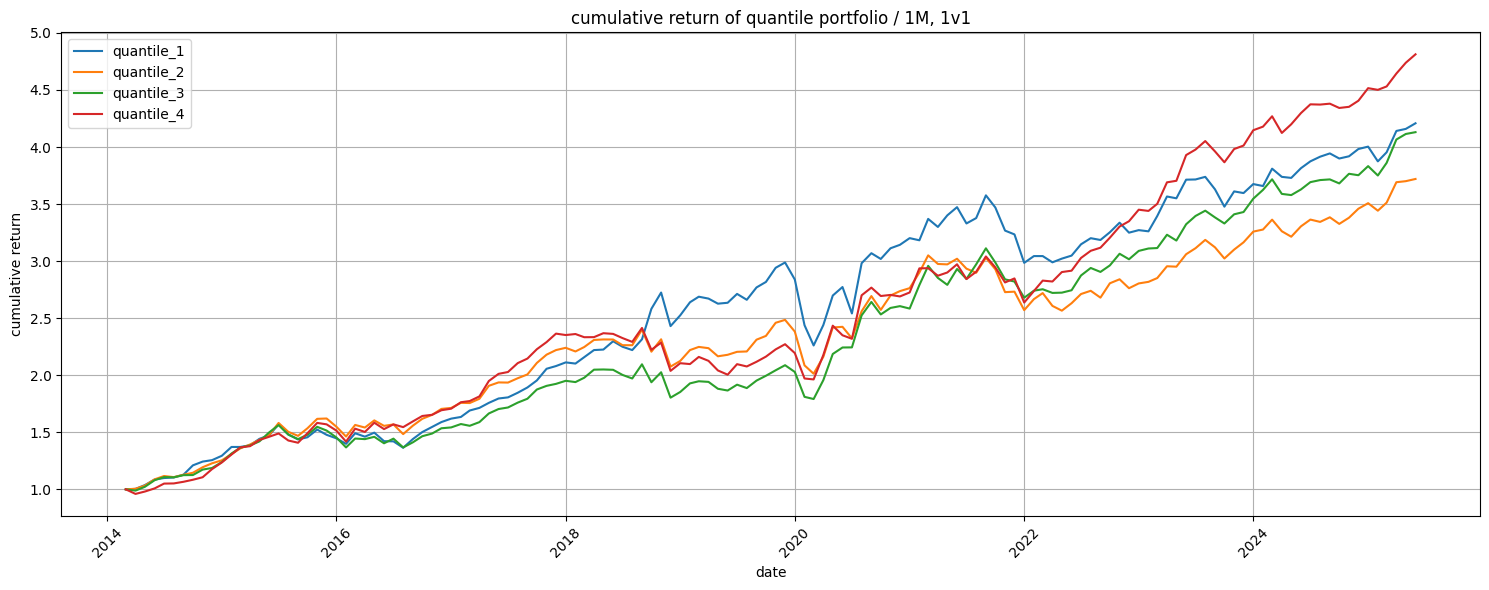

In [86]:
def plot_portfolio_returns(portfolio_returns):
    plt.figure(figsize=(15, 6))
    for col in portfolio_returns.columns:

        # 累計リターンを計算
        cumulative_returns = (1 + portfolio_returns[col]).cumprod()
        
        # 初月が1になるように調整
        cumulative_returns = cumulative_returns / cumulative_returns.iloc[0]

        plt.plot(portfolio_returns.index, 
        cumulative_returns, 
        label=col)

    plt.title(f'cumulative return of quantile portfolio / {compare_month}M, 1v1')
    plt.xlabel('date')
    plt.ylabel('cumulative return')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# set date index
portfolio_returns.index = pd.to_datetime(portfolio_returns.index)

# visualize growth rate
plot_portfolio_returns(portfolio_returns)

AttributeError: 'dict' object has no attribute 'columns'

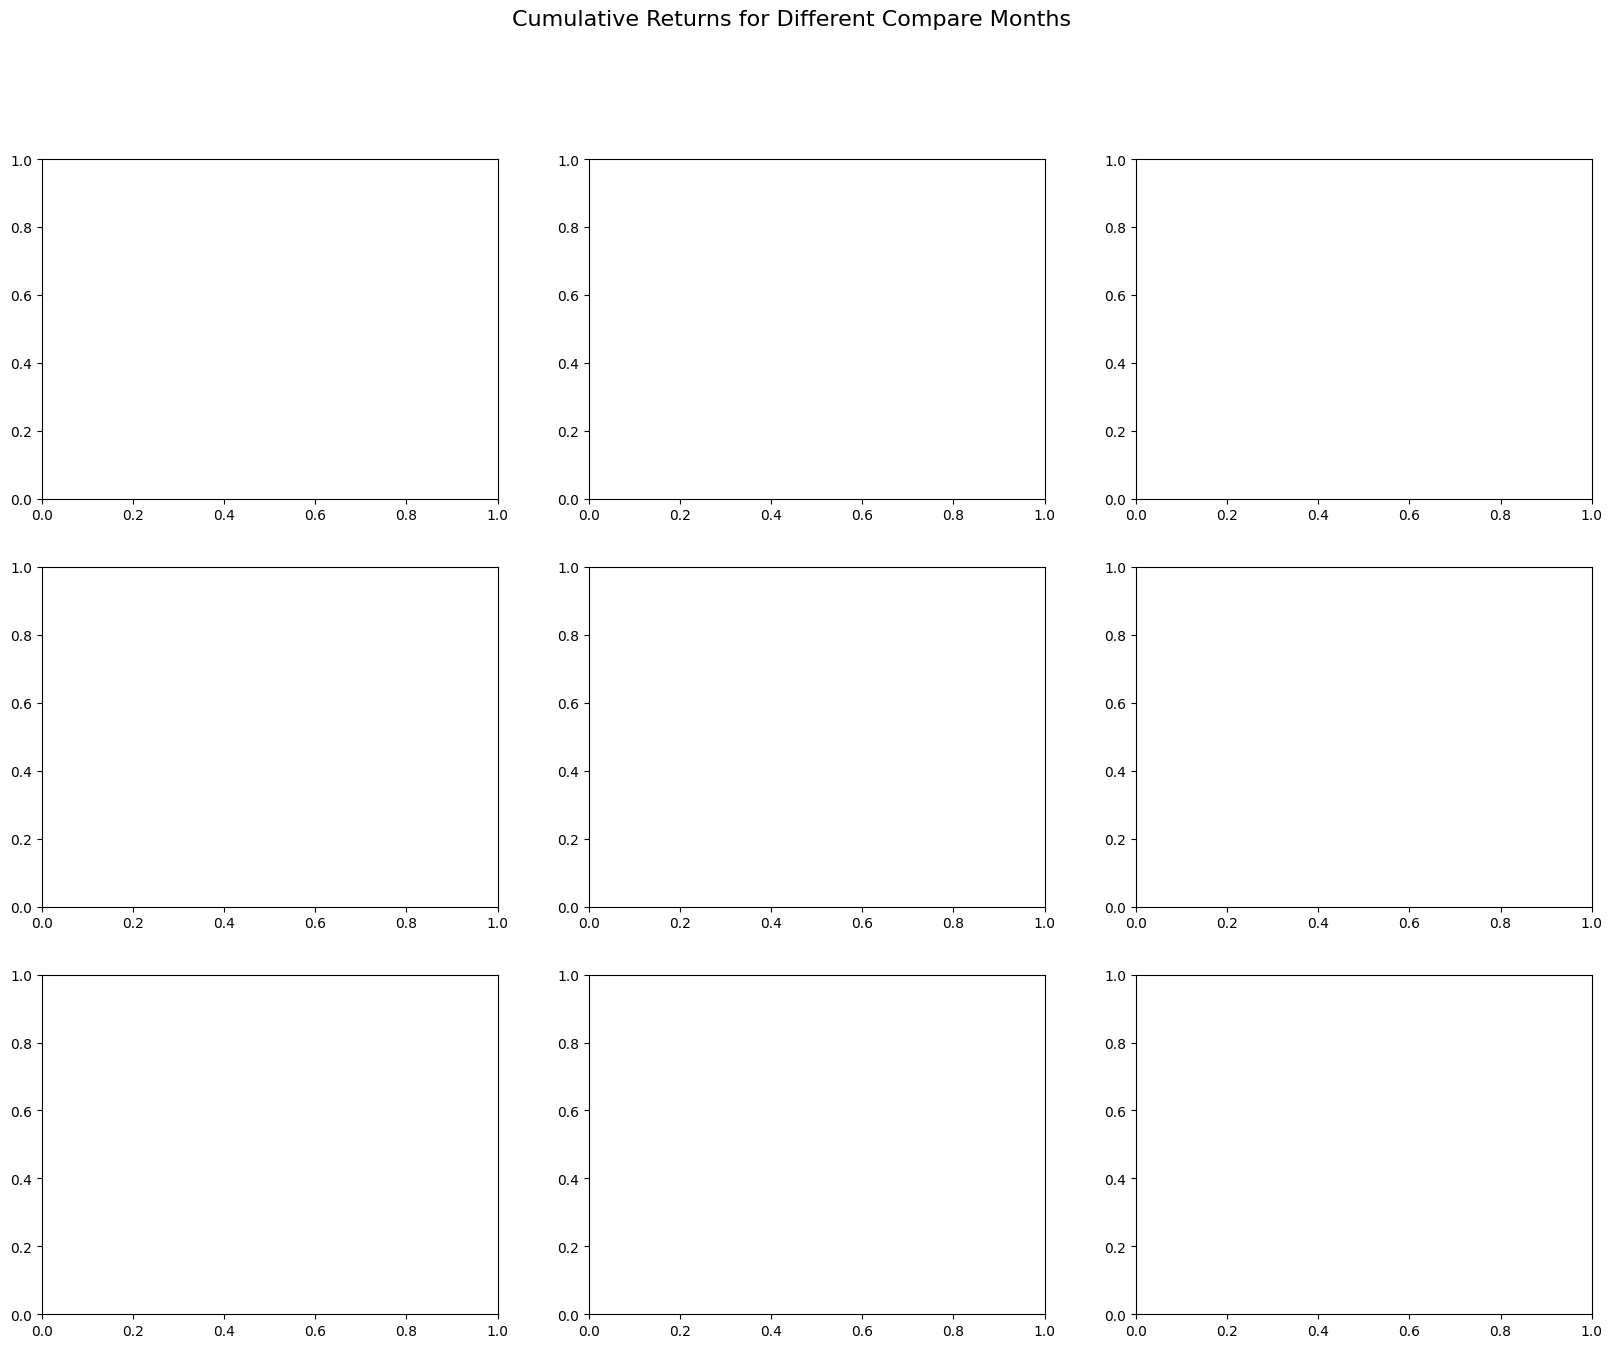

In [87]:
def plot_portfolio_returns(portfolio_returns, compare_month):
    # 3x3のサブプロットを作成
    fig, axes = plt.subplots(3, 3, figsize=(20, 15))
    fig.suptitle('Cumulative Returns for Different Compare Months', fontsize=16)
    
    # 各サブプロットにデータをプロット
    for i, month in enumerate(range(1, 10)):
        row = i // 3
        col = i % 3
        ax = axes[row, col]
        
        for col_name in portfolio_returns.columns:
            # 累計リターンを計算
            cumulative_returns = (1 + portfolio_returns[col_name]).cumprod()
            # 初月が1になるように調整
            cumulative_returns = cumulative_returns / cumulative_returns.iloc[0]
            
            ax.plot(portfolio_returns.index, 
                   cumulative_returns, 
                   label=col_name)
        
        ax.set_title(f'Compare Month: {month}M')
        ax.set_xlabel('Date')
        ax.set_ylabel('Cumulative Return')
        ax.legend()
        ax.grid(True)
        ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig(f'../data/output/all_months_comparison.png')
    plt.close()

# 各compare_monthの結果を保存するための辞書
portfolio_results = {}

# 1から9までの各月で計算を実行
for month in range(1, 10):
    compare_month = month
    # ここで各月の計算を実行し、結果をportfolio_resultsに保存
    # portfolio_results[month] = 計算結果

# 最終的なプロット
plot_portfolio_returns(portfolio_results, compare_month)